Using GPU: Tesla V100-PCIE-32GB

================ Seed 42 ================

Standard BP    | test_loss=1.0009 | test_acc=0.7721 | epochs_to_target=6
Geometry-local | test_loss=0.8652 | test_acc=0.7851 | test_ce=0.8040 | test_local=6.1271 | epochs_to_target=7

================ Seed 43 ================

Standard BP    | test_loss=1.0379 | test_acc=0.7695 | epochs_to_target=5
Geometry-local | test_loss=0.8469 | test_acc=0.7835 | test_ce=0.7945 | test_local=5.2377 | epochs_to_target=6

================ Seed 44 ================

Standard BP    | test_loss=0.9443 | test_acc=0.7844 | epochs_to_target=7
Geometry-local | test_loss=0.9335 | test_acc=0.7732 | test_ce=0.8721 | test_local=6.1471 | epochs_to_target=9

================ Seed 45 ================

Standard BP    | test_loss=0.9435 | test_acc=0.7781 | epochs_to_target=6
Geometry-local | test_loss=0.7708 | test_acc=0.8002 | test_ce=0.7189 | test_local=5.1878 | epochs_to_target=8

================ Seed 46 ================

Standard BP    |

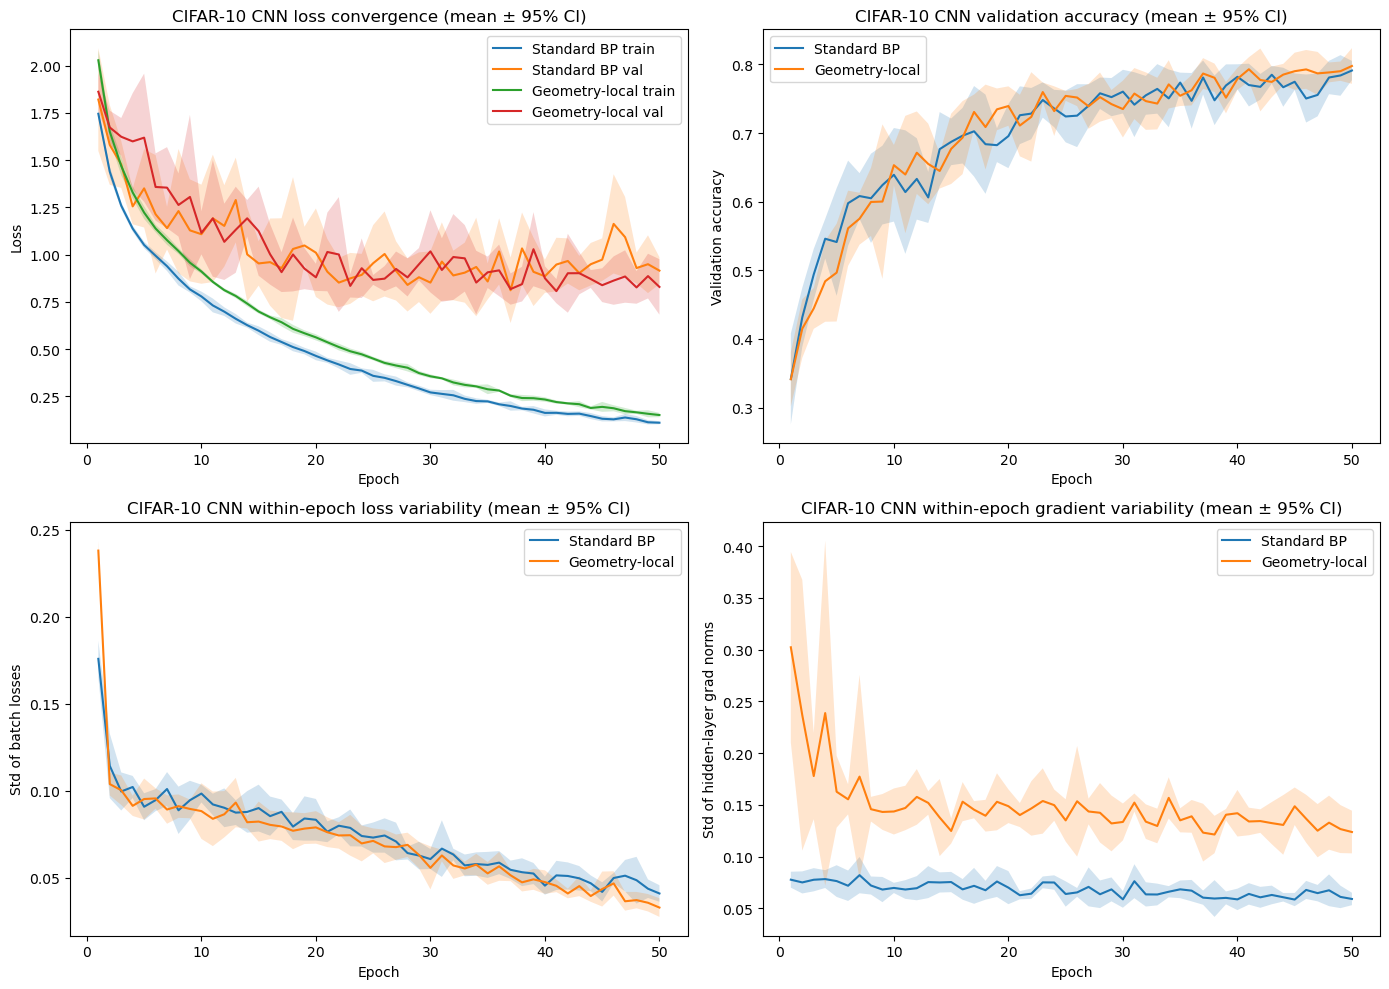

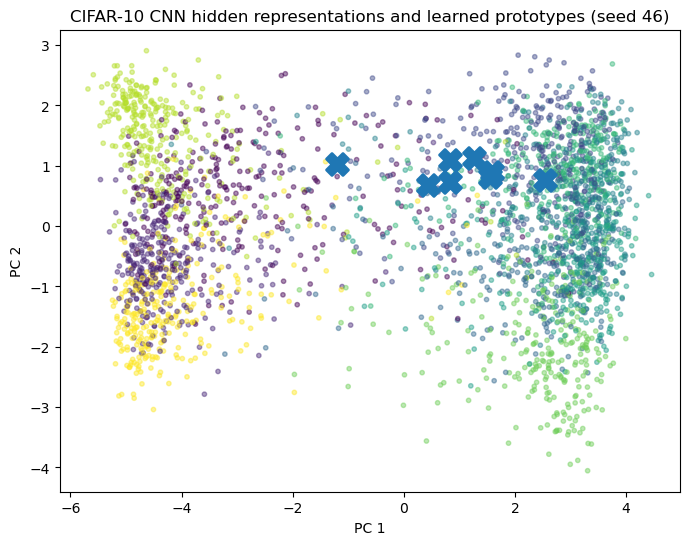

In [3]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ============================================================
# Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

# ============================================================
# Global settings
# ============================================================
NUM_SEEDS = 5
SEEDS = [42, 43, 44, 45, 46]

hidden_dim = 256
epochs = 50
lr = 1e-3

# Geometry-local hyperparameters
lambda_local = 0.01
num_prototypes = 8
tau = 1.0

batch_size_train = 128
batch_size_eval = 256

# For CNN on CIFAR-10, 0.60 is a reasonable threshold for quick runs
target_acc = 0.60

# Quick-run option:
# None -> full CIFAR-10 training set
# 10000 -> use 10k training samples before train/val split
train_subset_size = 10000

# 95% CI t-critical value for df = 4 (5 seeds)
T_CRIT_95_DF4 = 2.776

# ============================================================
# Reproducibility helper
# ============================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# ============================================================
# CIFAR-10 loaders
# Train uses augmentation, validation/test do not
# ============================================================
def make_cifar10_loaders(seed: int):
    set_seed(seed)

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2023, 0.1994, 0.2010)
        )
    ])

    eval_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2023, 0.1994, 0.2010)
        )
    ])

    train_full_aug = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=train_transform
    )

    train_full_eval = datasets.CIFAR10(
        root="./data",
        train=True,
        download=False,
        transform=eval_transform
    )

    test_set = datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=eval_transform
    )

    # Optional subset
    if train_subset_size is not None and train_subset_size < len(train_full_aug):
        g_subset = torch.Generator().manual_seed(seed)
        subset_indices = torch.randperm(len(train_full_aug), generator=g_subset)[:train_subset_size].tolist()
    else:
        subset_indices = list(range(len(train_full_aug)))

    # Deterministic train/val split from subset indices
    n_total = len(subset_indices)
    n_val = int(0.1 * n_total)
    n_train = n_total - n_val

    g_split = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n_total, generator=g_split).tolist()

    train_indices = [subset_indices[i] for i in perm[:n_train]]
    val_indices = [subset_indices[i] for i in perm[n_train:]]

    train_set = Subset(train_full_aug, train_indices)
    val_set = Subset(train_full_eval, val_indices)

    g_loader = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size_train,
        shuffle=True,
        generator=g_loader,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_set,
        batch_size=batch_size_eval,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_set,
        batch_size=batch_size_eval,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader

# ============================================================
# CNN backbone
# Produces penultimate feature vector h(x)
# ============================================================
class SmallCNNBackbone(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 16 -> 8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.feature_proj = nn.Linear(256, hidden_dim)

    def forward(self, x):
        feat = self.features(x)                     # [B, 256, 1, 1]
        feat = feat.view(feat.size(0), -1)         # [B, 256]
        h = torch.tanh(self.feature_proj(feat))    # [B, hidden_dim]
        return h

# ============================================================
# Standard CNN classifier
# ============================================================
class StandardCNN(nn.Module):
    def __init__(self, hidden_dim=256, out_dim=10):
        super().__init__()
        self.backbone = SmallCNNBackbone(hidden_dim=hidden_dim)
        self.classifier = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        h = self.backbone(x)
        logits = self.classifier(h)
        return logits, h

# ============================================================
# Geometry-local CNN
# Prototype-conditioned head on top of CNN features
# ============================================================
class GeometryLocalCNN(nn.Module):
    def __init__(self, hidden_dim=256, out_dim=10, num_prototypes=8, tau=1.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        self.K = num_prototypes
        self.tau = tau

        self.backbone = SmallCNNBackbone(hidden_dim=hidden_dim)

        self.prototypes = nn.Parameter(torch.randn(num_prototypes, hidden_dim) * 0.5)
        self.phi = nn.Parameter(torch.randn(num_prototypes, hidden_dim) * 0.5)

        self.expert_W = nn.Parameter(torch.randn(num_prototypes, out_dim, hidden_dim) * 0.05)
        self.expert_b = nn.Parameter(torch.zeros(num_prototypes, out_dim))

    def memberships(self, h):
        dist_sq = torch.cdist(h, self.prototypes, p=2.0) ** 2
        g = F.softmax(-dist_sq / self.tau, dim=1)
        return g

    def forward(self, x):
        h = self.backbone(x)                       # [B, H]
        g = self.memberships(h)                    # [B, K]

        # [K, C, H] x [B, H] -> [B, K, C]
        expert_logits = torch.einsum("kch,bh->bkc", self.expert_W, h) + self.expert_b.unsqueeze(0)

        logits = torch.sum(g.unsqueeze(-1) * expert_logits, dim=1)
        local_target = g @ self.phi
        local_loss = 0.5 * torch.mean(torch.sum((h - local_target) ** 2, dim=1))

        return logits, h, g, local_loss

# ============================================================
# Utilities
# ============================================================
def evaluate_standard(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            logits, _ = model(xb)
            loss = F.cross_entropy(logits, yb)

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n


def evaluate_geometry(model, loader, lambda_local=0.01):
    model.eval()
    total_loss = 0.0
    total_ce = 0.0
    total_loc = 0.0
    total_correct = 0
    total_n = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            logits, _, _, local_loss = model(xb)
            ce = F.cross_entropy(logits, yb)
            loss = ce + lambda_local * local_loss

            total_loss += loss.item() * xb.size(0)
            total_ce += ce.item() * xb.size(0)
            total_loc += local_loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_n += xb.size(0)

    return {
        "loss": total_loss / total_n,
        "ce": total_ce / total_n,
        "local": total_loc / total_n,
        "acc": total_correct / total_n
    }


def grad_norm(module):
    sq = 0.0
    for p in module.parameters():
        if p.grad is not None:
            sq += p.grad.detach().pow(2).sum().item()
    return math.sqrt(sq + 1e-12)


def epochs_to_threshold(acc_curve, threshold=0.60):
    for i, a in enumerate(acc_curve, start=1):
        if a >= threshold:
            return i
    return np.nan


def mean_ci95(arr, axis=0):
    arr = np.asarray(arr, dtype=np.float64)
    mean = np.mean(arr, axis=axis)

    if arr.shape[axis] == 1:
        ci = np.zeros_like(mean)
    else:
        std = np.std(arr, axis=axis, ddof=1)
        n = arr.shape[axis]
        ci = T_CRIT_95_DF4 * std / np.sqrt(n)

    return mean, ci


def fmt_mean_ci(mean_val, ci_val, digits=4):
    return f"{mean_val:.{digits}f} ± {ci_val:.{digits}f}"

# ============================================================
# Training: Standard BP
# ============================================================
def train_standard(model, train_loader, val_loader, epochs=50, lr=1e-3, verbose=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "batch_loss_std": [],
        "batch_grad_std": [],
        "batch_grad_mean": [],
    }

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        batch_grad_norms = []

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad()
            logits, _ = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()

            gnorm = grad_norm(model.backbone.feature_proj)
            batch_grad_norms.append(gnorm)

            opt.step()
            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_loss, val_acc = evaluate_standard(model, val_loader)

        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        hist["val_acc"].append(val_acc)
        hist["batch_loss_std"].append(float(np.std(batch_losses)))
        hist["batch_grad_std"].append(float(np.std(batch_grad_norms)))
        hist["batch_grad_mean"].append(float(np.mean(batch_grad_norms)))

        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(
                f"[STD] Epoch {epoch+1:03d} | "
                f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f} | grad_std={hist['batch_grad_std'][-1]:.4f}"
            )

    return hist

# ============================================================
# Training: Geometry-local
# ============================================================
def train_geometry(model, train_loader, val_loader, epochs=50, lr=1e-3, lambda_local=0.01, verbose=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {
        "train_loss": [],
        "train_ce": [],
        "train_local": [],
        "val_loss": [],
        "val_acc": [],
        "val_ce": [],
        "val_local": [],
        "batch_loss_std": [],
        "batch_grad_std": [],
        "batch_grad_mean": [],
    }

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        batch_ces = []
        batch_locs = []
        batch_grad_norms = []

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad()
            logits, _, _, local_loss = model(xb)
            ce = F.cross_entropy(logits, yb)
            loss = ce + lambda_local * local_loss
            loss.backward()

            gnorm = grad_norm(model.backbone.feature_proj)
            batch_grad_norms.append(gnorm)

            opt.step()

            batch_losses.append(loss.item())
            batch_ces.append(ce.item())
            batch_locs.append(local_loss.item())

        train_loss = float(np.mean(batch_losses))
        train_ce = float(np.mean(batch_ces))
        train_loc = float(np.mean(batch_locs))
        val_metrics = evaluate_geometry(model, val_loader, lambda_local=lambda_local)

        hist["train_loss"].append(train_loss)
        hist["train_ce"].append(train_ce)
        hist["train_local"].append(train_loc)
        hist["val_loss"].append(val_metrics["loss"])
        hist["val_acc"].append(val_metrics["acc"])
        hist["val_ce"].append(val_metrics["ce"])
        hist["val_local"].append(val_metrics["local"])
        hist["batch_loss_std"].append(float(np.std(batch_losses)))
        hist["batch_grad_std"].append(float(np.std(batch_grad_norms)))
        hist["batch_grad_mean"].append(float(np.mean(batch_grad_norms)))

        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(
                f"[GEO] Epoch {epoch+1:03d} | "
                f"train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
                f"val_acc={val_metrics['acc']:.4f} | grad_std={hist['batch_grad_std'][-1]:.4f}"
            )

    return hist

# ============================================================
# Run one seed
# ============================================================
def run_one_seed(seed: int, verbose=False):
    print(f"\n================ Seed {seed} ================\n")
    set_seed(seed)
    train_loader, val_loader, test_loader = make_cifar10_loaders(seed)

    std_model = StandardCNN(hidden_dim=hidden_dim, out_dim=10)
    geo_model = GeometryLocalCNN(
        hidden_dim=hidden_dim,
        out_dim=10,
        num_prototypes=num_prototypes,
        tau=tau
    )

    hist_std = train_standard(
        std_model,
        train_loader,
        val_loader,
        epochs=epochs,
        lr=lr,
        verbose=verbose
    )

    hist_geo = train_geometry(
        geo_model,
        train_loader,
        val_loader,
        epochs=epochs,
        lr=lr,
        lambda_local=lambda_local,
        verbose=verbose
    )

    std_test_loss, std_test_acc = evaluate_standard(std_model, test_loader)
    geo_test_metrics = evaluate_geometry(geo_model, test_loader, lambda_local=lambda_local)

    std_epochs_to_target = epochs_to_threshold(hist_std["val_acc"], threshold=target_acc)
    geo_epochs_to_target = epochs_to_threshold(hist_geo["val_acc"], threshold=target_acc)

    result = {
        "seed": seed,
        "hist_std": hist_std,
        "hist_geo": hist_geo,
        "metrics_std": {
            "test_loss": std_test_loss,
            "test_acc": std_test_acc,
            "epochs_to_target": float(std_epochs_to_target if std_epochs_to_target is not None else np.nan),
            "avg_batch_loss_std": float(np.mean(hist_std["batch_loss_std"])),
            "avg_hidden_grad_std": float(np.mean(hist_std["batch_grad_std"])),
        },
        "metrics_geo": {
            "test_loss": geo_test_metrics["loss"],
            "test_acc": geo_test_metrics["acc"],
            "test_ce": geo_test_metrics["ce"],
            "test_local": geo_test_metrics["local"],
            "epochs_to_target": float(geo_epochs_to_target if geo_epochs_to_target is not None else np.nan),
            "avg_batch_loss_std": float(np.mean(hist_geo["batch_loss_std"])),
            "avg_hidden_grad_std": float(np.mean(hist_geo["batch_grad_std"])),
        },
        "geo_model": geo_model,
        "test_loader": test_loader,
    }

    print(
        "Standard BP    | "
        f"test_loss={result['metrics_std']['test_loss']:.4f} | "
        f"test_acc={result['metrics_std']['test_acc']:.4f} | "
        f"epochs_to_target={result['metrics_std']['epochs_to_target']:.0f}"
    )

    print(
        "Geometry-local | "
        f"test_loss={result['metrics_geo']['test_loss']:.4f} | "
        f"test_acc={result['metrics_geo']['test_acc']:.4f} | "
        f"test_ce={result['metrics_geo']['test_ce']:.4f} | "
        f"test_local={result['metrics_geo']['test_local']:.4f} | "
        f"epochs_to_target={result['metrics_geo']['epochs_to_target']:.0f}"
    )

    return result

# ============================================================
# Run all seeds
# ============================================================
all_results = []
for seed in SEEDS:
    res = run_one_seed(seed, verbose=False)
    all_results.append(res)

# ============================================================
# Aggregate scalar metrics
# ============================================================
std_test_loss_arr = np.array([r["metrics_std"]["test_loss"] for r in all_results])
std_test_acc_arr = np.array([r["metrics_std"]["test_acc"] for r in all_results])
std_epochs_arr = np.array([r["metrics_std"]["epochs_to_target"] for r in all_results])
std_batch_loss_std_arr = np.array([r["metrics_std"]["avg_batch_loss_std"] for r in all_results])
std_hidden_grad_std_arr = np.array([r["metrics_std"]["avg_hidden_grad_std"] for r in all_results])

geo_test_loss_arr = np.array([r["metrics_geo"]["test_loss"] for r in all_results])
geo_test_acc_arr = np.array([r["metrics_geo"]["test_acc"] for r in all_results])
geo_test_ce_arr = np.array([r["metrics_geo"]["test_ce"] for r in all_results])
geo_test_local_arr = np.array([r["metrics_geo"]["test_local"] for r in all_results])
geo_epochs_arr = np.array([r["metrics_geo"]["epochs_to_target"] for r in all_results])
geo_batch_loss_std_arr = np.array([r["metrics_geo"]["avg_batch_loss_std"] for r in all_results])
geo_hidden_grad_std_arr = np.array([r["metrics_geo"]["avg_hidden_grad_std"] for r in all_results])

# ============================================================
# Aggregate curves
# ============================================================
std_train_loss_curves = np.array([r["hist_std"]["train_loss"] for r in all_results])
std_val_loss_curves = np.array([r["hist_std"]["val_loss"] for r in all_results])
std_val_acc_curves = np.array([r["hist_std"]["val_acc"] for r in all_results])
std_batch_loss_std_curves = np.array([r["hist_std"]["batch_loss_std"] for r in all_results])
std_batch_grad_std_curves = np.array([r["hist_std"]["batch_grad_std"] for r in all_results])

geo_train_loss_curves = np.array([r["hist_geo"]["train_loss"] for r in all_results])
geo_val_loss_curves = np.array([r["hist_geo"]["val_loss"] for r in all_results])
geo_val_acc_curves = np.array([r["hist_geo"]["val_acc"] for r in all_results])
geo_batch_loss_std_curves = np.array([r["hist_geo"]["batch_loss_std"] for r in all_results])
geo_batch_grad_std_curves = np.array([r["hist_geo"]["batch_grad_std"] for r in all_results])

std_train_loss_mean, std_train_loss_ci = mean_ci95(std_train_loss_curves, axis=0)
std_val_loss_mean, std_val_loss_ci = mean_ci95(std_val_loss_curves, axis=0)
std_val_acc_mean, std_val_acc_ci = mean_ci95(std_val_acc_curves, axis=0)
std_batch_loss_std_mean, std_batch_loss_std_ci = mean_ci95(std_batch_loss_std_curves, axis=0)
std_batch_grad_std_mean, std_batch_grad_std_ci = mean_ci95(std_batch_grad_std_curves, axis=0)

geo_train_loss_mean, geo_train_loss_ci = mean_ci95(geo_train_loss_curves, axis=0)
geo_val_loss_mean, geo_val_loss_ci = mean_ci95(geo_val_loss_curves, axis=0)
geo_val_acc_mean, geo_val_acc_ci = mean_ci95(geo_val_acc_curves, axis=0)
geo_batch_loss_std_mean, geo_batch_loss_std_ci = mean_ci95(geo_batch_loss_std_curves, axis=0)
geo_batch_grad_std_mean, geo_batch_grad_std_ci = mean_ci95(geo_batch_grad_std_curves, axis=0)

# ============================================================
# Print summary
# ============================================================
std_test_loss_mean, std_test_loss_ci = mean_ci95(std_test_loss_arr)
std_test_acc_mean, std_test_acc_ci = mean_ci95(std_test_acc_arr)
std_epochs_mean, std_epochs_ci = mean_ci95(std_epochs_arr)
std_batch_loss_mean, std_batch_loss_ci = mean_ci95(std_batch_loss_std_arr)
std_hidden_grad_mean, std_hidden_grad_ci = mean_ci95(std_hidden_grad_std_arr)

geo_test_loss_mean, geo_test_loss_ci = mean_ci95(geo_test_loss_arr)
geo_test_acc_mean, geo_test_acc_ci = mean_ci95(geo_test_acc_arr)
geo_test_ce_mean, geo_test_ce_ci = mean_ci95(geo_test_ce_arr)
geo_test_local_mean, geo_test_local_ci = mean_ci95(geo_test_local_arr)
geo_epochs_mean, geo_epochs_ci = mean_ci95(geo_epochs_arr)
geo_batch_loss_mean, geo_batch_loss_ci = mean_ci95(geo_batch_loss_std_arr)
geo_hidden_grad_mean, geo_hidden_grad_ci = mean_ci95(geo_hidden_grad_std_arr)

print("\n================ CIFAR-10 CNN Aggregated Results over 5 Seeds (mean ± 95% CI) ================\n")

print("Standard BP")
print(f"  test_loss             : {fmt_mean_ci(std_test_loss_mean, std_test_loss_ci)}")
print(f"  test_acc              : {fmt_mean_ci(std_test_acc_mean, std_test_acc_ci)}")
print(f"  epochs_to_target      : {fmt_mean_ci(std_epochs_mean, std_epochs_ci)}")
print(f"  avg_batch_loss_std    : {fmt_mean_ci(std_batch_loss_mean, std_batch_loss_ci)}")
print(f"  avg_hidden_grad_std   : {fmt_mean_ci(std_hidden_grad_mean, std_hidden_grad_ci)}")

print("\nGeometry-local")
print(f"  test_loss             : {fmt_mean_ci(geo_test_loss_mean, geo_test_loss_ci)}")
print(f"  test_acc              : {fmt_mean_ci(geo_test_acc_mean, geo_test_acc_ci)}")
print(f"  test_ce               : {fmt_mean_ci(geo_test_ce_mean, geo_test_ce_ci)}")
print(f"  test_local            : {fmt_mean_ci(geo_test_local_mean, geo_test_local_ci)}")
print(f"  epochs_to_target      : {fmt_mean_ci(geo_epochs_mean, geo_epochs_ci)}")
print(f"  avg_batch_loss_std    : {fmt_mean_ci(geo_batch_loss_mean, geo_batch_loss_ci)}")
print(f"  avg_hidden_grad_std   : {fmt_mean_ci(geo_hidden_grad_mean, geo_hidden_grad_ci)}")

# ============================================================
# Plot mean curves with 95% CI
# ============================================================
epochs_arr = np.arange(1, epochs + 1)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs_arr, std_train_loss_mean, label="Standard BP train")
plt.fill_between(
    epochs_arr,
    std_train_loss_mean - std_train_loss_ci,
    std_train_loss_mean + std_train_loss_ci,
    alpha=0.20
)
plt.plot(epochs_arr, std_val_loss_mean, label="Standard BP val")
plt.fill_between(
    epochs_arr,
    std_val_loss_mean - std_val_loss_ci,
    std_val_loss_mean + std_val_loss_ci,
    alpha=0.20
)

plt.plot(epochs_arr, geo_train_loss_mean, label="Geometry-local train")
plt.fill_between(
    epochs_arr,
    geo_train_loss_mean - geo_train_loss_ci,
    geo_train_loss_mean + geo_train_loss_ci,
    alpha=0.20
)
plt.plot(epochs_arr, geo_val_loss_mean, label="Geometry-local val")
plt.fill_between(
    epochs_arr,
    geo_val_loss_mean - geo_val_loss_ci,
    geo_val_loss_mean + geo_val_loss_ci,
    alpha=0.20
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CIFAR-10 CNN loss convergence (mean ± 95% CI)")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epochs_arr, std_val_acc_mean, label="Standard BP")
plt.fill_between(
    epochs_arr,
    std_val_acc_mean - std_val_acc_ci,
    std_val_acc_mean + std_val_acc_ci,
    alpha=0.20
)

plt.plot(epochs_arr, geo_val_acc_mean, label="Geometry-local")
plt.fill_between(
    epochs_arr,
    geo_val_acc_mean - geo_val_acc_ci,
    geo_val_acc_mean + geo_val_acc_ci,
    alpha=0.20
)

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("CIFAR-10 CNN validation accuracy (mean ± 95% CI)")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epochs_arr, std_batch_loss_std_mean, label="Standard BP")
plt.fill_between(
    epochs_arr,
    std_batch_loss_std_mean - std_batch_loss_std_ci,
    std_batch_loss_std_mean + std_batch_loss_std_ci,
    alpha=0.20
)

plt.plot(epochs_arr, geo_batch_loss_std_mean, label="Geometry-local")
plt.fill_between(
    epochs_arr,
    geo_batch_loss_std_mean - geo_batch_loss_std_ci,
    geo_batch_loss_std_mean + geo_batch_loss_std_ci,
    alpha=0.20
)

plt.xlabel("Epoch")
plt.ylabel("Std of batch losses")
plt.title("CIFAR-10 CNN within-epoch loss variability (mean ± 95% CI)")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epochs_arr, std_batch_grad_std_mean, label="Standard BP")
plt.fill_between(
    epochs_arr,
    std_batch_grad_std_mean - std_batch_grad_std_ci,
    std_batch_grad_std_mean + std_batch_grad_std_ci,
    alpha=0.20
)

plt.plot(epochs_arr, geo_batch_grad_std_mean, label="Geometry-local")
plt.fill_between(
    epochs_arr,
    geo_batch_grad_std_mean - geo_batch_grad_std_ci,
    geo_batch_grad_std_mean + geo_batch_grad_std_ci,
    alpha=0.20
)

plt.xlabel("Epoch")
plt.ylabel("Std of hidden-layer grad norms")
plt.title("CIFAR-10 CNN within-epoch gradient variability (mean ± 95% CI)")
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# Hidden representations and prototypes for last seed
# PCA to 2D for visualization
# ============================================================
def pca_project(X, n_components=2):
    X = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    components = Vt[:n_components]
    Z = X @ components.T
    return Z, components, np.mean(X, axis=0, keepdims=True)

last_result = all_results[-1]
geo_model_last = last_result["geo_model"]
test_loader_last = last_result["test_loader"]

geo_model_last.eval()
hs = []
ys = []

with torch.no_grad():
    count = 0
    for xb, yb in test_loader_last:
        xb = xb.to(device, non_blocking=True)
        _, h, _, _ = geo_model_last(xb)
        hs.append(h.cpu())
        ys.append(yb.cpu())
        count += xb.size(0)
        if count >= 3000:
            break

h_all = torch.cat(hs, dim=0)[:3000].numpy()
y_all = torch.cat(ys, dim=0)[:3000].numpy()
proto = geo_model_last.prototypes.detach().cpu().numpy()

h_mean = np.mean(h_all, axis=0, keepdims=True)
h_centered = h_all - h_mean
U, S, Vt = np.linalg.svd(h_centered, full_matrices=False)
components = Vt[:2]

h_2d = h_centered @ components.T
proto_2d = (proto - h_mean) @ components.T

plt.figure(figsize=(8, 6))
plt.scatter(h_2d[:, 0], h_2d[:, 1], c=y_all, alpha=0.45, s=10)
plt.scatter(proto_2d[:, 0], proto_2d[:, 1], marker="X", s=250, linewidths=2)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title(f"CIFAR-10 CNN hidden representations and learned prototypes (seed {last_result['seed']})")
plt.show()